# VaR and Expected Shortfall Comparison with Tenokonda Sobol' Sequence

In this notebook we keep the same discretely monitored **geometric Asian call**, but move from pricing to **scenario generation and tail-risk estimation** for a **short** position.

## Tail measures for a short geometric Asian call

For a monitoring dimension $d$, let $G_d$ denote the discrete geometric average of the underlying stock path and let $A_0(d)$ be the corresponding time-zero option value. The discounted loss of the short call is
$$
L_d = e^{-rT}(G_d-K)^+ - A_0(d).
$$

We compare deterministic Sobol' scenario generation through two standard tail summaries at confidence level $\alpha$:
$$
\mathrm{VaR}_{\alpha}(L_d),
\qquad
\mathrm{ES}_{\alpha}(L_d).
$$

Because $\log G_d \sim N(m_d, v_d)$ with the same
$$
m_d = \log S_0 + \left(r-\tfrac12\sigma^2\right)T\frac{d+1}{2d},
\qquad
v_d = \sigma^2 T\frac{(d+1)(2d+1)}{6d^2},
$$
as in the Asian-pricing notebook, closed-form benchmarks are available. Writing $s_d = \sqrt{v_d}$ and $z_\alpha = N^{-1}(\alpha)$, the positive-tail formulas are
$$
\mathrm{VaR}_{\alpha}(L_d)
= e^{-rT}\left(e^{m_d + s_d z_\alpha} - K\right) - A_0(d),
$$
$$
\mathrm{ES}_{\alpha}(L_d)
= e^{-rT}\left(\frac{e^{m_d + \tfrac12 v_d}N(s_d-z_\alpha)}{1-\alpha} - K\right) - A_0(d),
$$
which apply here because we choose $\alpha$ high enough to lie above the atom at the premium-only outcome.

In [1]:
from pricing_helper import *
from plotting_helper import plot_with_error_panel
from tklds.interface.generators import get_sequence_enum

In [2]:
num_paths = 2**12
spot = 100.0
strike = 100.0
rate = 0.05
volatility = 0.2
expiry = 0.5
alpha = 0.975

tk_dimension_grid_a = np.arange(2, 50001)
jk_dimension_grid_b = np.arange(2, 21021)

sequence_enum = get_sequence_enum()

tk_sequence = sequence_enum.TKRG_A_AP5
jk_sequence = sequence_enum.NEW_JOE_KUO

tk_normals = sobol_normal_matrix(
    num_paths=num_paths,
    num_dimensions=int(tk_dimension_grid_a.max()),
    sequence=tk_sequence,
)
jk_normals = sobol_normal_matrix(
    num_paths=num_paths,
    num_dimensions=int(jk_dimension_grid_b.max()),
    sequence=jk_sequence,
)

In [3]:
reference_var, reference_es, tk_var, jk_var, tk_es, jk_es = run_sobol_short_geometric_asian_var_es_comparison(
    spot=spot,
    strike=strike,
    rate=rate,
    volatility=volatility,
    expiry=expiry,
    alpha=alpha,
    z_a=tk_normals,
    z_b=jk_normals,
    dimension_grid_a=tk_dimension_grid_a,
    dimension_grid_b=jk_dimension_grid_b,
)

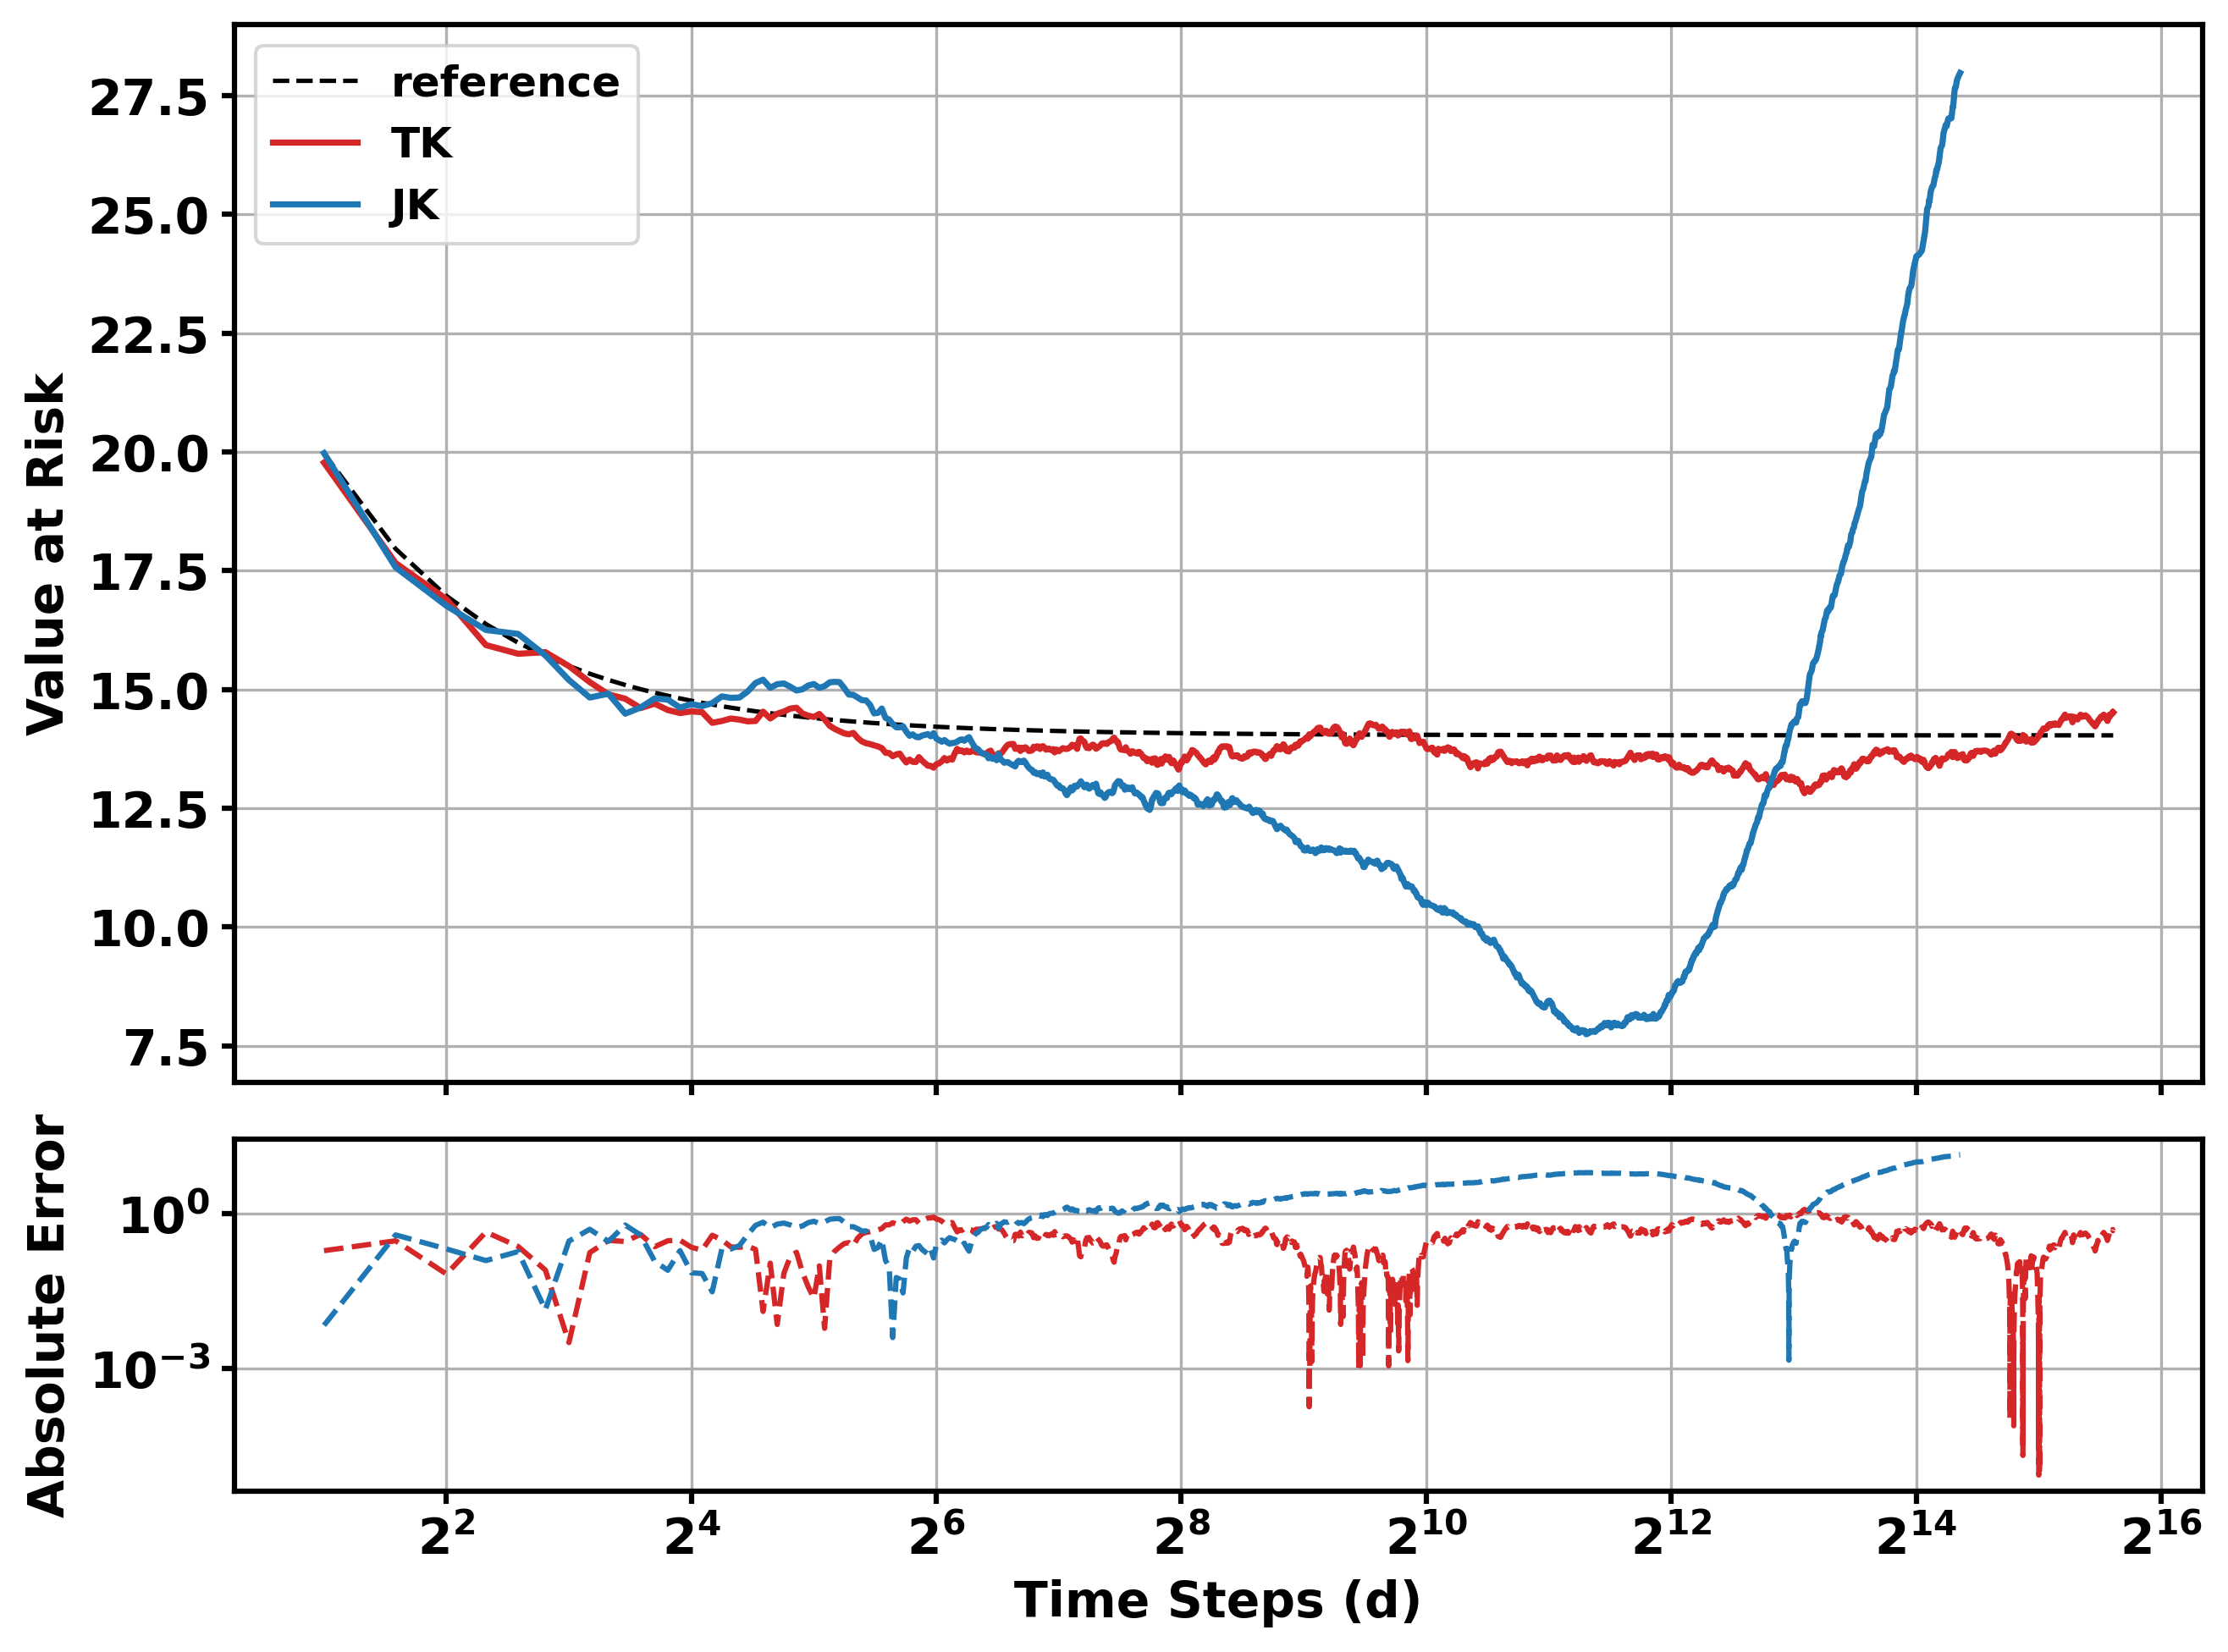

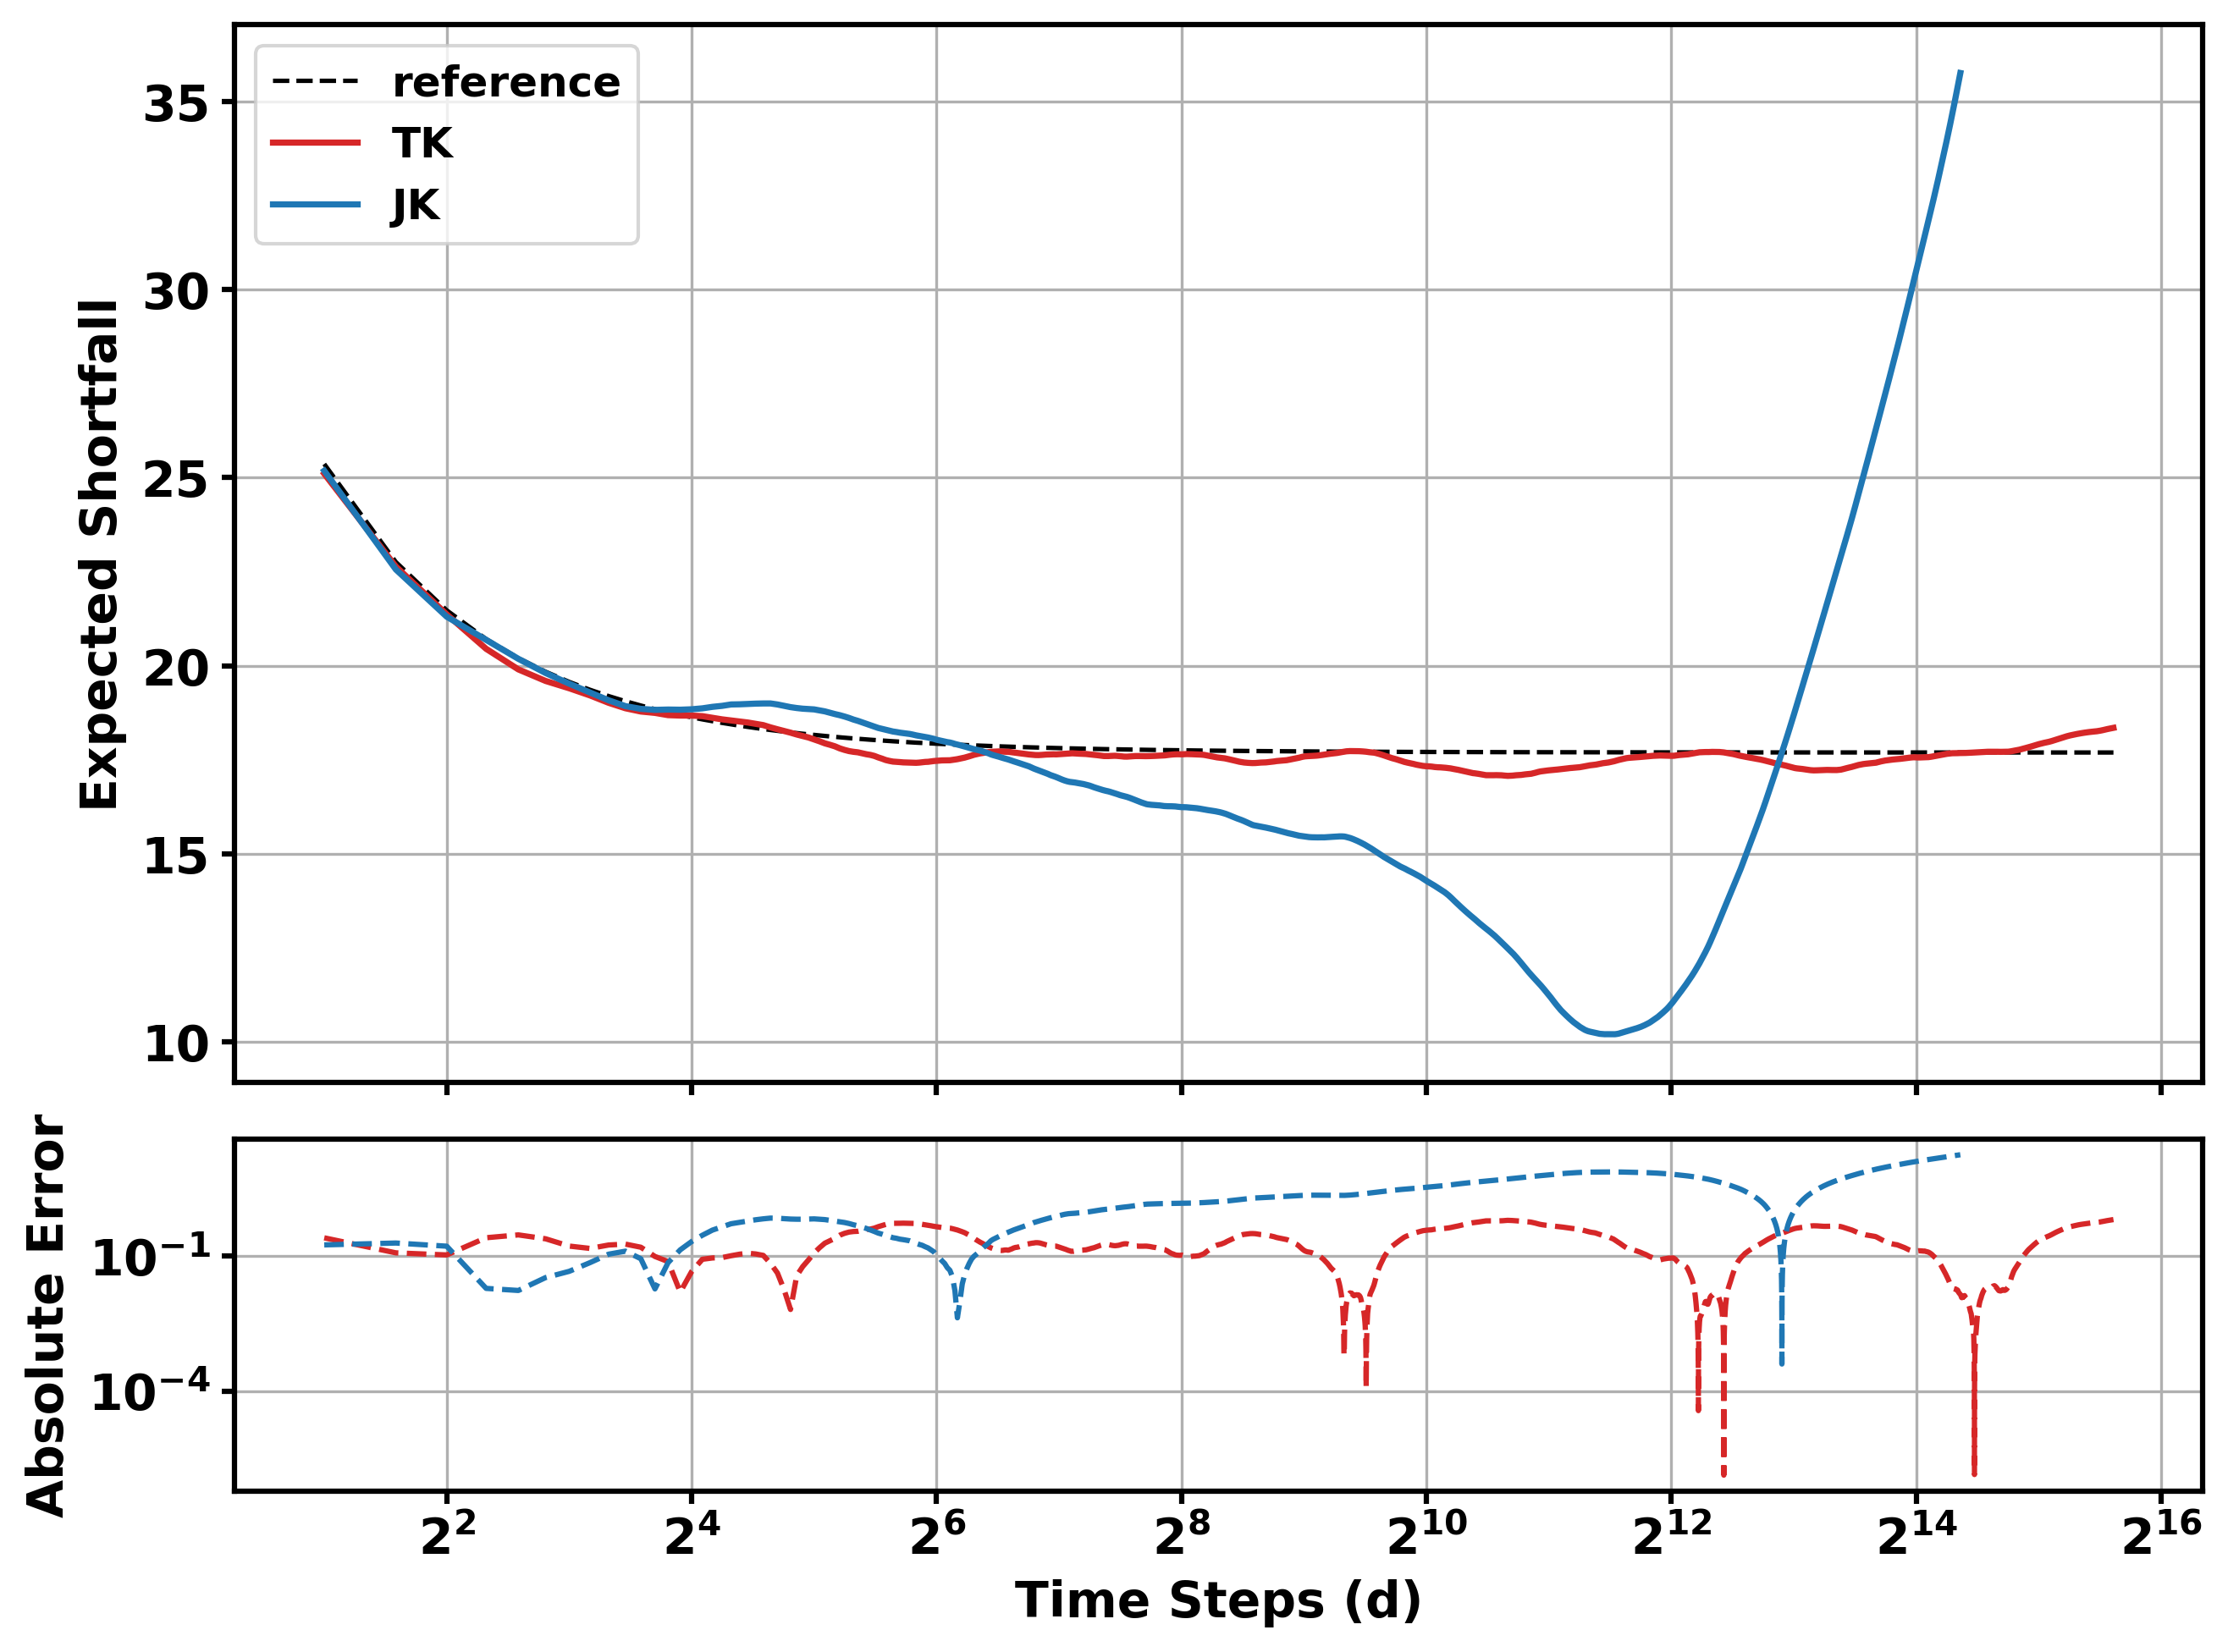

(<Figure size 3000x2250 with 2 Axes>,
 (<Axes: ylabel='Expected Shortfall'>,
  <Axes: xlabel='Time Steps (d)', ylabel='Absolute Error'>))

In [4]:
plot_with_error_panel(
    x_data=[tk_dimension_grid_a, jk_dimension_grid_b],
    y_data=[tk_var, jk_var],
    y_axis_label_top='Value at Risk',
    y_axis_label_bottom='Absolute Error',
    x_axis_label='Time Steps (d)',
    y_data_label=['TK', 'JK'],
    y_data_colors=['tab:red', 'tab:blue'],
    reference_x_data=tk_dimension_grid_a,
    reference_y_data=reference_var,
)
plot_with_error_panel(
    x_data=[tk_dimension_grid_a, jk_dimension_grid_b],
    y_data=[tk_es, jk_es],
    y_axis_label_top='Expected Shortfall',
    y_axis_label_bottom='Absolute Error',
    x_axis_label='Time Steps (d)',
    y_data_label=['TK', 'JK'],
    y_data_colors=['tab:red', 'tab:blue'],
    reference_x_data=tk_dimension_grid_a,
    reference_y_data=reference_es,
)